In [31]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/sample_data/Mall_Customers (2).csv")

# Display the first 10 rows
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [32]:
# Check missing values in the required columns
missing_values = df[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


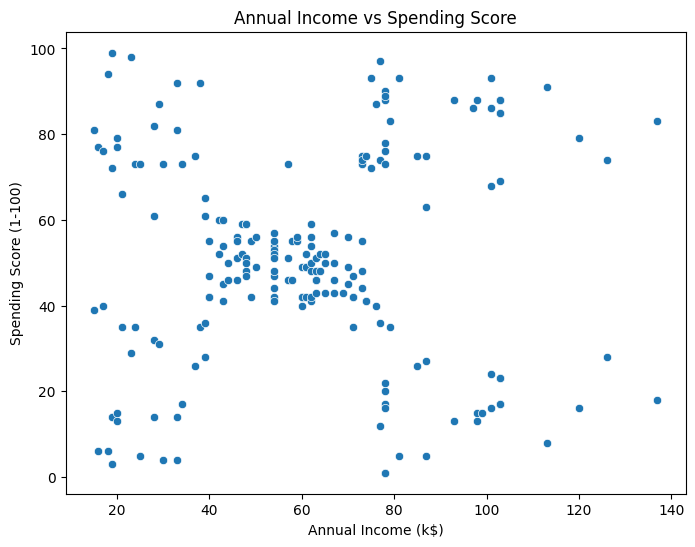

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatterplot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [34]:
# Select numerical columns
numerical_features = df.select_dtypes(include=["number"])

# Calculate correlation matrix
correlation_matrix = numerical_features.corr()

# Display correlation matrix
print(correlation_matrix)

                        CustomerID       Age  Annual Income (k$)  \
CustomerID                1.000000 -0.026918            0.979499   
Age                      -0.026918  1.000000           -0.011594   
Annual Income (k$)        0.979499 -0.011594            1.000000   
Spending Score (1-100)    0.022024 -0.353177            0.014297   

                        Spending Score (1-100)  
CustomerID                            0.022024  
Age                                  -0.353177  
Annual Income (k$)                    0.014297  
Spending Score (1-100)                1.000000  


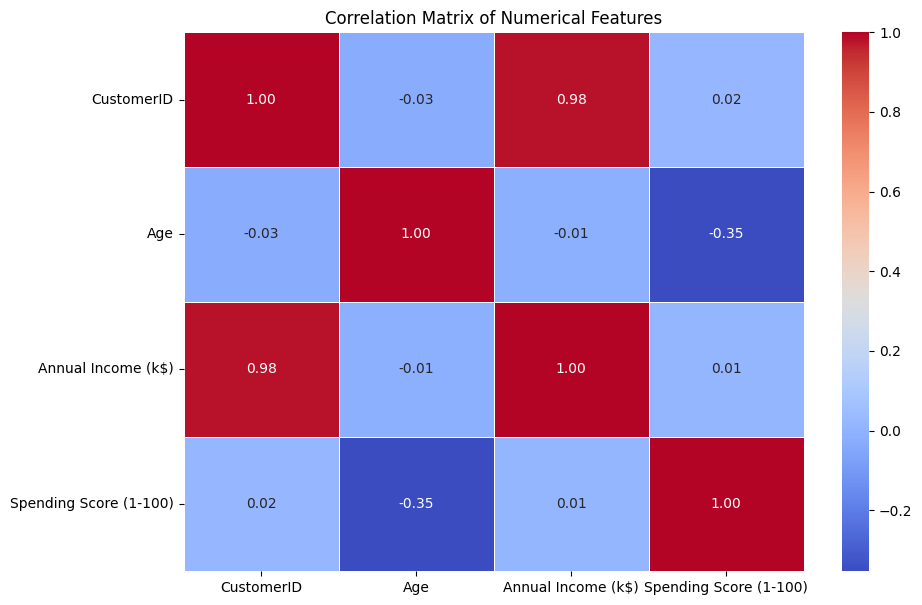

In [35]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

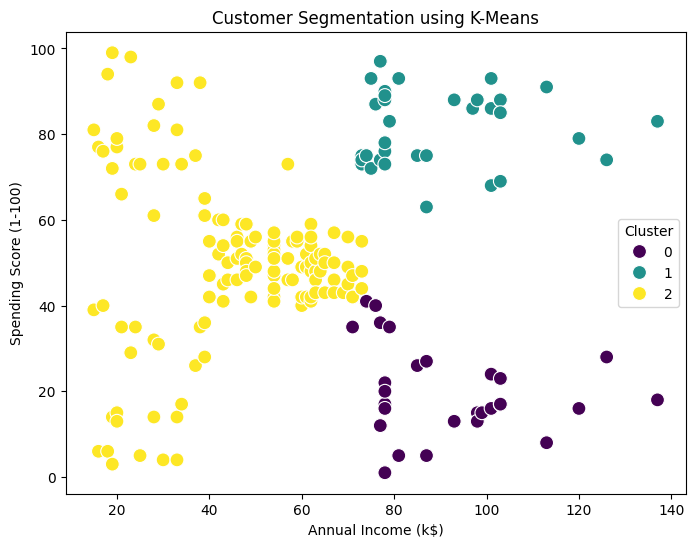

In [37]:
from sklearn.cluster import KMeans

# Select only the two required features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
df["Cluster"] = kmeans.fit_predict(X)

# Display the first 10 rows
df.head(10)


plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()